# 1. Data loading and EDA


## Loading dataset


In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "MonoHime/ru_sentiment_dataset",
    data_files={
        "full": "datasets.csv",
        "train": "train.csv",
        "valid": "valid.csv",
    }
)


In [3]:
full_dataset = dataset['full']
full_dataset.to_csv('full_dataset.csv')

Creating CSV from Arrow format:   0%|          | 0/211 [00:00<?, ?ba/s]

307163723

## EDA


In [1]:
import pandas as pd

df_full = pd.read_csv('full_dataset.csv', index_col = 0).reset_index(drop = True)
df_full.sample(10)

,text,sentiment
124876,Благодарность специалисту массажа Елене\nХотел...,1
210237,Купила я своего Марчика (Nissan March)в 2008 г...,1
130333,Если снимать на длительный срок студию с кухне...,0
21032,Отличная клиника\nВсегда доброжелательное отно...,1
45902,Довелось остановить на одну ночь в этом отеле....,1
93021,"Там в районе парка целая улица, если не две.\n",0
39906,"Машанка очень резвая , удобная , вм...",0
100156,останавливалась в данном отеле на пхукете в фе...,0
39513,"Ужас\nОбратились с подругой 5.02.14 г., с остр...",2
172163,На 1 декабря была назначена свадьба . Неделю ...,2


In [2]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 210989 entries, 0 to 210988
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   text       210989 non-null  str  
 1   sentiment  210989 non-null  int64
dtypes: int64(1), str(1)
memory usage: 293.9 MB


### Labels meaning:
```
0: NEUTRAL
1: POSITIVE
2: NEGATIVE
```

In [3]:
df_full.describe()

,sentiment
count,210989.000000
mean,1.002005
std,0.722694
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


sentiment
1    100792
2     55310
0     54887
Name: count, dtype: int64


<Axes: xlabel='sentiment'>

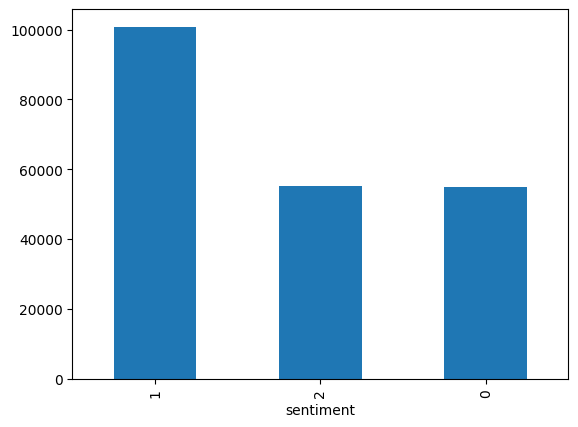

In [4]:
print(df_full['sentiment'].value_counts())
df_full['sentiment'].value_counts().plot(kind ='bar')

### Missing values

In [5]:
df_full.isna().mean()

text         0.0
sentiment    0.0
dtype: float64

### Duplicates

In [6]:
df_full['text'].duplicated().sum()

np.int64(10539)

### Texts with different sentiments

In [7]:
conflict_sentiments = df_full.groupby('text')['sentiment'].nunique()
conflict_texts = conflict_sentiments[conflict_sentiments>1].index

print('conflict texts:',len(conflict_texts))

mask = df_full['text'].isin(conflict_texts)
print('rows with conflict texts:', sum(mask))

conflict texts: 3664
rows with conflict texts: 9439


Тк 3664 текстов имеют различные целевые метки, стоит удалить их все, а не только дубликаты,  
поскольку мы не знаем, какой sentiment стоит оставить, а какой удалить. 

In [8]:
df_clean = df_full[~df_full['text'].isin(conflict_texts)].copy()

print('duplicates:', df_clean.duplicated('text').sum())
df_clean = df_clean.drop_duplicates(subset = ['text']).reset_index(drop = True)

print("duplicates after cleaning:", df_clean["text"].duplicated().sum())
print("conflicts after cleaning:", (df_clean.groupby("text")["sentiment"].nunique() > 1).sum())

duplicates: 4764
duplicates after cleaning: 0
conflicts after cleaning: 0


sentiment
1    93429
2    54104
0    49253
Name: count, dtype: int64


<Axes: xlabel='sentiment'>

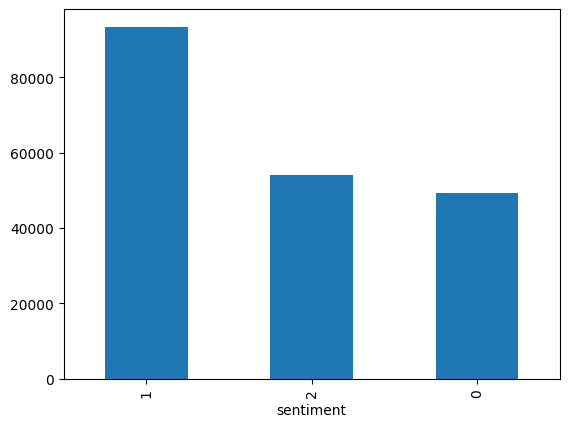

In [9]:
print(df_clean['sentiment'].value_counts())
df_clean['sentiment'].value_counts().plot(kind ='bar')

### Text analysis

In [10]:
df_clean['len'] = df_clean['text'].str.len()
df_clean['len'].describe()

count    196786.000000
mean        775.049389
std        2023.857929
min           3.000000
25%         267.000000
50%         471.000000
75%         861.000000
max      381498.000000
Name: len, dtype: float64

In [11]:
df_clean['n_words'] = df_clean['text'].str.split().str.len()
df_clean['n_words'].describe()

count    196786.000000
mean        116.832341
std         266.943739
min           1.000000
25%          39.000000
50%          71.000000
75%         132.000000
max       48146.000000
Name: n_words, dtype: float64

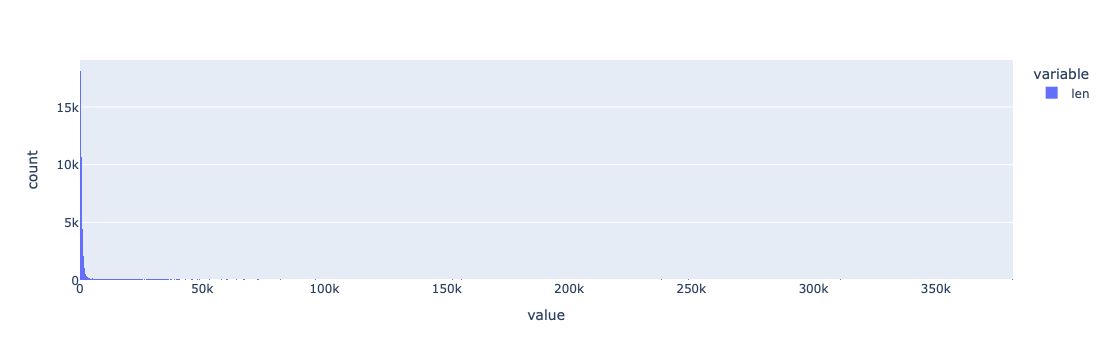

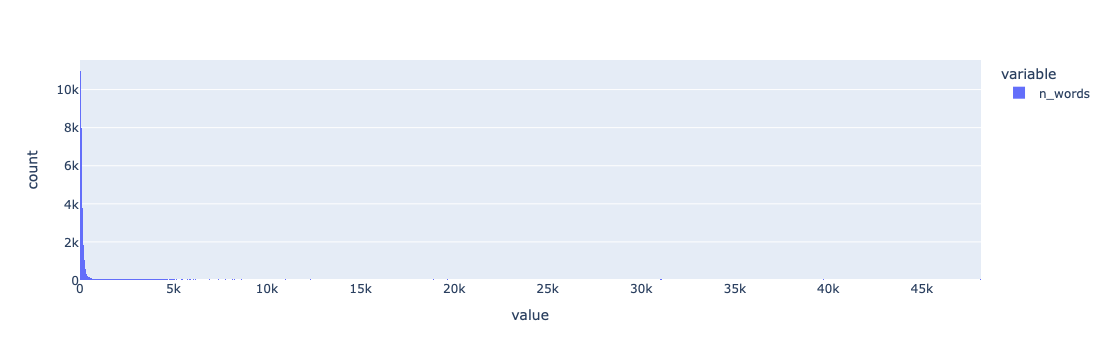

In [12]:
import plotly.express as px

px.histogram(df_clean['len']).show()
px.histogram(df_clean['n_words']).show()

### EDA summary

После очистки осталось 196786 уникальных текстов без пропусков, текстовых дубликатов и конфликтующих sentiment-меток. Исходно было найдено 3664 уникальных текста, которые встречались с разными целевыми метками; такие примеры были удалены полностью, так как для них невозможно однозначно восстановить правильный класс.

Распределение классов несбалансировано: положительный класс самый частый, нейтральный и отрицательный встречаются реже. Длины текстов имеют выраженный правый хвост: большинство документов относительно короткие, но есть очень длинные выбросы. Это важно учитывать при выборе `MAX_LENGTH` для transformer-классификатора и при тематическом моделировании.


In [2]:
df_clean.drop(columns = ['len', 'n_words']).to_csv('df.csv', index = False)

In [ ]:
# Сохранили очищенный датасет на диск, дальше сырой DataFrame уже не нужен
import gc

for name in ["df_full", "df_clean"]:
    if name in globals():
        del globals()[name]

gc.collect()

# 2. Topic modeling

### Все эксперименты выполнялись на MacBook Pro 14 M1 Pro 16/512

## NMF over TF-IDF baseline

In [21]:
import pandas as pd
df_clean = pd.read_csv('df.csv')

In [22]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
rus_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/artemzmailov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
import re
import pymorphy3
from functools import lru_cache
from sklearn.feature_extraction.text import TfidfVectorizer

morph = pymorphy3.MorphAnalyzer()
russian_token_pattern = re.compile(r"(?u)\b[а-яёa-z]{2,}\b")
russian_stop_words = set(rus_stop_words)

@lru_cache(maxsize=200_000)
def normalize_token(token):
    return morph.parse(token)[0].normal_form


def lemma_tokenizer(text):
    tokens = russian_token_pattern.findall(str(text).lower())
    lemmas = [normalize_token(token) for token in tokens]
    return [lemma for lemma in lemmas if lemma not in russian_stop_words and len(lemma) > 2]


tf_idf = TfidfVectorizer(
    max_features=20_000,
    min_df=10,
    max_df=0.5,
    ngram_range=(1, 2),
    tokenizer=lemma_tokenizer,
    token_pattern=None,
    lowercase=False
)

X = tf_idf.fit_transform(df_clean['text'])


In [24]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12483778 stored elements and shape (196786, 20000)>

После ограничения словаря размерность `TF-IDF`-матрицы снизилась с 485947 до 20000 признаков, 
при этом количество ненулевых элементов изменилось незначительно.  
Это говорит о том, что были в основном удалены редкие и малоинформативные признаки, а основная лексическая информация корпуса сохранилась.  
Такое представление более удобно для `NMF`: оно быстрее обучается и даёт более интерпретируемые темы.


In [25]:
from sklearn.decomposition import NMF

n_topics = 10
nmf = NMF(
    n_components = 10,
    random_state=42,
    max_iter = 1000
)
topic_matrix = nmf.fit_transform(X)
topic_words_matrix = nmf.components_

In [26]:
topic_words_matrix

array([[0.00000000e+00, 6.37136290e-04, 2.42860329e-04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        9.01870554e-03, 4.41866762e-03, 4.44784998e-03],
       ...,
       [0.00000000e+00, 2.01006788e-02, 1.40162717e-02, ...,
        0.00000000e+00, 2.83830555e-03, 5.11107225e-03],
       [0.00000000e+00, 0.00000000e+00, 1.48763890e-05, ...,
        0.00000000e+00, 1.94024827e-03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.20871653e-03, 2.14654148e-03]],
      shape=(10, 20000))

In [27]:
feature_names = tf_idf.get_feature_names_out()
n_top_words = 20

for idx, topic_weights in enumerate(topic_words_matrix):
    print(f'Topic {idx+1}:')
    top_indices = topic_weights.argsort()[:-n_top_words-1:-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f'Top {n_top_words} words:')
    print(top_words)
    print()

Topic 1:
Top 20 words:
['отель', 'очень', 'завтрак', 'центр', 'персонал', 'рядом', 'хороший', 'расположить', 'это отель', 'пляж', 'минута', 'находиться', 'отличный', 'бассейн', 'расположение', 'отель очень', 'город', 'достопримечательность', 'останавливаться', 'отель расположить']

Topic 2:
Top 20 words:
['врач', 'приём', 'поликлиника', 'анализ', 'больница', 'узи', 'пациент', 'лечение', 'диагноз', 'отношение', 'хороший', 'сказать', 'очень', 'регистратура', 'очередь', 'гинеколог', 'прийти', 'кабинет', 'беременность', 'попасть']

Topic 3:
Top 20 words:
['это', 'всё', 'мочь', 'человек', 'который', 'ещё', 'сказать', 'просто', 'свой', 'весь', 'говорить', 'знать', 'вообще', 'день', 'время', 'деньга', 'делать', 'сделать', 'место', 'хотя']

Topic 4:
Top 20 words:
['очень', 'ресторан', 'понравиться', 'кухня', 'обслуживание', 'всё', 'вкусный', 'блюдо', 'очень понравиться', 'вкусно', 'официант', 'интерьер', 'хороший', 'еда', 'приятный', 'зал', 'свадьба', 'место', 'гость', 'уютный']

Topic 5:
Top 

In [28]:
df_clean['nmf_topic'] = topic_matrix.argmax(axis=1)

nmf_topic
0    18945
1    23348
2    40129
3    26796
4    15381
5    11427
6     7947
7    11109
8     9163
9    32541
Name: count, dtype: int64


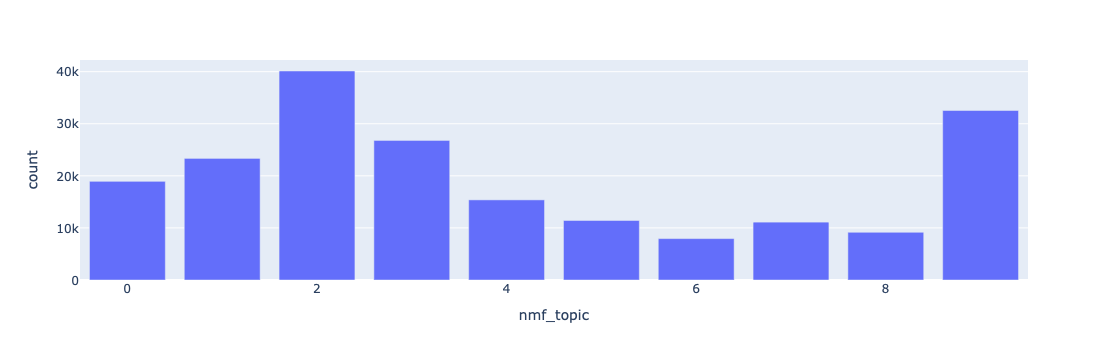

In [30]:
import plotly.express as px
topics_dist = df_clean['nmf_topic'].value_counts().sort_index()
print(topics_dist)
px.bar(topics_dist, y = 'count')

In [ ]:
# После baseline NMF освобождаем самые тяжёлые объекты TF-IDF/NMF
import gc

for name in ["X", "tf_idf", "nmf", "topic_matrix", "topic_words_matrix", "feature_names"]:
    if name in globals():
        del globals()[name]

gc.collect()

## BERTopic over Granite embeddings

В качестве более современного подхода используется `BERTopic` с эмбеддингами `ibm-granite/granite-embedding-97m-multilingual-r2`.  
Эта модель занимает 2 место в бенчмарке `MTEB` среди моделей <100M.  
В отличие от `TF-IDF` + `NMF`, этот подход группирует тексты по плотным семантическим представлениям, а не только по совпадению слов. Модель Granite выбрана как компромисс между качеством и вычислительной стоимостью: она компактная, поддерживает русский язык и позволяет строить эмбеддинги для большого корпуса на локальном устройстве.


In [5]:
import pandas as pd
df_clean = pd.read_csv('df.csv')

In [6]:
import torch
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device

'mps'

In [7]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = None  # для полного корпуса поставить None

if SAMPLE_SIZE is None:
    bertopic_df = df_clean.copy()
else:
    _, bertopic_df = train_test_split(
        df_clean,
        test_size=SAMPLE_SIZE,
        random_state=42,
        shuffle=True,
        stratify=df_clean["sentiment"]
    )

docs = bertopic_df["text"].astype(str).to_list()
docs_prefixed = ["categorize_topic: " + text for text in docs]

print("Documents for BERTopic:", len(docs))


Documents for BERTopic: 196786


In [4]:
import gc
import time
import psutil
import numpy as np
import torch
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

device = "mps" if torch.backends.mps.is_available() else "cpu"

model = SentenceTransformer(
    "ibm-granite/granite-embedding-97m-multilingual-r2",
    device=device
)

model.max_seq_length = 512

process = psutil.Process()

def rss_gb():
    return process.memory_info().rss / 1024**3

print("device:", device)
print(f"rss after model load: {rss_gb():.2f} GB")


Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

device: mps
rss after model load: 2.07 GB


In [5]:
N = len(docs_prefixed)
CHUNK_SIZE = 1000
INNER_BATCH_SIZE = 8

embedding_batches = []

start = time.time()

for start_idx in range(0, N, CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, N)

    batch_embeddings = model.encode(
        docs_prefixed[start_idx:end_idx],
        batch_size=INNER_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    embedding_batches.append(batch_embeddings)

    del batch_embeddings
    gc.collect()

    if device == "mps":
        torch.mps.empty_cache()

    print(
        f"{end_idx}/{N} | rss={rss_gb():.2f} GB | "
        f"time={(time.time() - start) / 60:.1f} min"
    )

embeddings = np.vstack(embedding_batches).astype("float32")

embedding_path = f"granite_embeddings_{N}.npy"
np.save(embedding_path, embeddings)

print("shape:", embeddings.shape)
print(f"total time: {(time.time() - start) / 60:.2f} min")
print("saved to:", embedding_path)


# Освобождаем память после самого тяжёлого этапа.
del model, embedding_batches, docs_prefixed
gc.collect()

if device == "mps":
    torch.mps.empty_cache()

print(f"rss after cleanup: {rss_gb():.2f} GB")


1000/196786 | rss=2.64 GB | time=0.3 min
2000/196786 | rss=3.00 GB | time=0.6 min
3000/196786 | rss=3.30 GB | time=0.9 min
4000/196786 | rss=3.47 GB | time=1.1 min
5000/196786 | rss=3.66 GB | time=1.4 min
6000/196786 | rss=3.83 GB | time=1.7 min
7000/196786 | rss=4.01 GB | time=2.0 min
8000/196786 | rss=4.10 GB | time=2.2 min
9000/196786 | rss=4.18 GB | time=2.5 min
10000/196786 | rss=4.25 GB | time=2.8 min
11000/196786 | rss=4.31 GB | time=3.1 min
12000/196786 | rss=4.37 GB | time=3.3 min
13000/196786 | rss=4.42 GB | time=3.6 min
14000/196786 | rss=4.47 GB | time=3.9 min
15000/196786 | rss=4.50 GB | time=4.1 min
16000/196786 | rss=4.55 GB | time=4.4 min
17000/196786 | rss=4.58 GB | time=4.7 min
18000/196786 | rss=4.61 GB | time=4.9 min
19000/196786 | rss=4.64 GB | time=5.2 min
20000/196786 | rss=4.65 GB | time=5.4 min
21000/196786 | rss=4.55 GB | time=5.7 min
22000/196786 | rss=4.14 GB | time=6.0 min
23000/196786 | rss=4.16 GB | time=6.2 min
24000/196786 | rss=3.93 GB | time=6.5 min
2

In [1]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
rus_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/artemzmailov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Перед запуском BERTopic можно использовать уже сохранённые эмбеддинги. Это позволяет не пересчитывать embedding-модель повторно: тяжёлый этап был выполнен один раз, а дальнейшие эксперименты с BERTopic используют файл `granite_embeddings_196786.npy`.


In [10]:
import numpy as np

embedding_path = f"granite_embeddings_{len(docs)}.npy"

try:
    embeddings
    print("Embeddings already loaded:", embeddings.shape)
except NameError:
    embeddings = np.load(embedding_path)
    print("Loaded embeddings from file:", embedding_path, embeddings.shape)

assert embeddings.shape[0] == len(docs)


Loaded embeddings from file: granite_embeddings_196786.npy (196786, 384)


In [11]:
import re
import time
import pymorphy3
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from functools import lru_cache

morph = pymorphy3.MorphAnalyzer()
russian_token_pattern = re.compile(r"(?u)\b[а-яёa-z]{2,}\b")
russian_stop_words = set(rus_stop_words)

@lru_cache(maxsize=200_000)
def normalize_token(token):
    return morph.parse(token)[0].normal_form


def lemma_tokenizer(text):
    tokens = russian_token_pattern.findall(str(text).lower())
    lemmas = [normalize_token(token) for token in tokens]
    return [lemma for lemma in lemmas if lemma not in russian_stop_words and len(lemma) > 2]


vectorizer_model = CountVectorizer(
    tokenizer=lemma_tokenizer,
    token_pattern=None,
    lowercase=False,
    min_df=10 if len(docs) > 50_000 else 5,
    max_df=0.5,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

start = time.time()

topics, _ = topic_model.fit_transform(docs, embeddings)

print(f"BERTopic time: {(time.time() - start) / 60:.2f} min")


2026-05-07 13:29:46,882 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-05-07 13:30:39,654 - BERTopic - Dimensionality - Completed ✓
2026-05-07 13:30:39,657 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 13:30:47,606 - BERTopic - Cluster - Completed ✓
2026-05-07 13:30:47,631 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 13:31:41,262 - BERTopic - Representation - Completed ✓


BERTopic time: 2.18 min


### Default BERTopic results


In [12]:
topic_info = topic_model.get_topic_info()
topic_info.head(30)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,114253,-1_номер_врач_клиника_отель,"[номер, врач, клиника, отель, ресторан, завтра...",[«Общественная позиция» (проект «DAT» №44 ...
1,0,6124,0_благодарность_отделение_выразить_огромный бл...,"[благодарность, отделение, выразить, огромный ...",[Благодарность гинекологическому отделению\nЛе...
2,1,4637,1_роддом_роды_рожать_акушерка,"[роддом, роды, рожать, акушерка, родить, схват...",[Больше туда я попасть бы не хотела\nСобиралас...
3,2,2833,2_регистратура_дозвониться_талон_трубка,"[регистратура, дозвониться, талон, трубка, зап...",[Невозможно дозвониться и записаться\nНикогда ...
4,3,2776,3_хохол_хуй_хуйня_пидор,"[хохол, хуй, хуйня, пидор, тред, нахуй, блядь,...","[Какие же хохлы всадники, пиздец просто.\n, Эт..."
5,4,2405,4_свадьба_гость_банкет_наш свадьба,"[свадьба, гость, банкет, наш свадьба, зал, тор...",[В конце июля 2004 года мы праздновали в Нюанс...
6,5,2107,5_барселона_каталония_площадь каталония_площадь,"[барселона, каталония, площадь каталония, площ...","[Отель расположен на Рамбле,на самой оживленно..."
7,6,1631,6_машина_автомобиль_салон_сидение,"[машина, автомобиль, салон, сидение, багажник,...",[В машину была влюблена давно. Очень нравилась...
8,7,1590,7_метро_станция метро_станция_рядом метро,"[метро, станция метро, станция, рядом метро, ц...","[Хороший отель, удобное расположение, близко к..."
9,8,1410,8_отель_это отель_спа_завтрак,"[отель, это отель, спа, завтрак, отель очень, ...",[Отель очень понравился своим дружелюбным и оч...


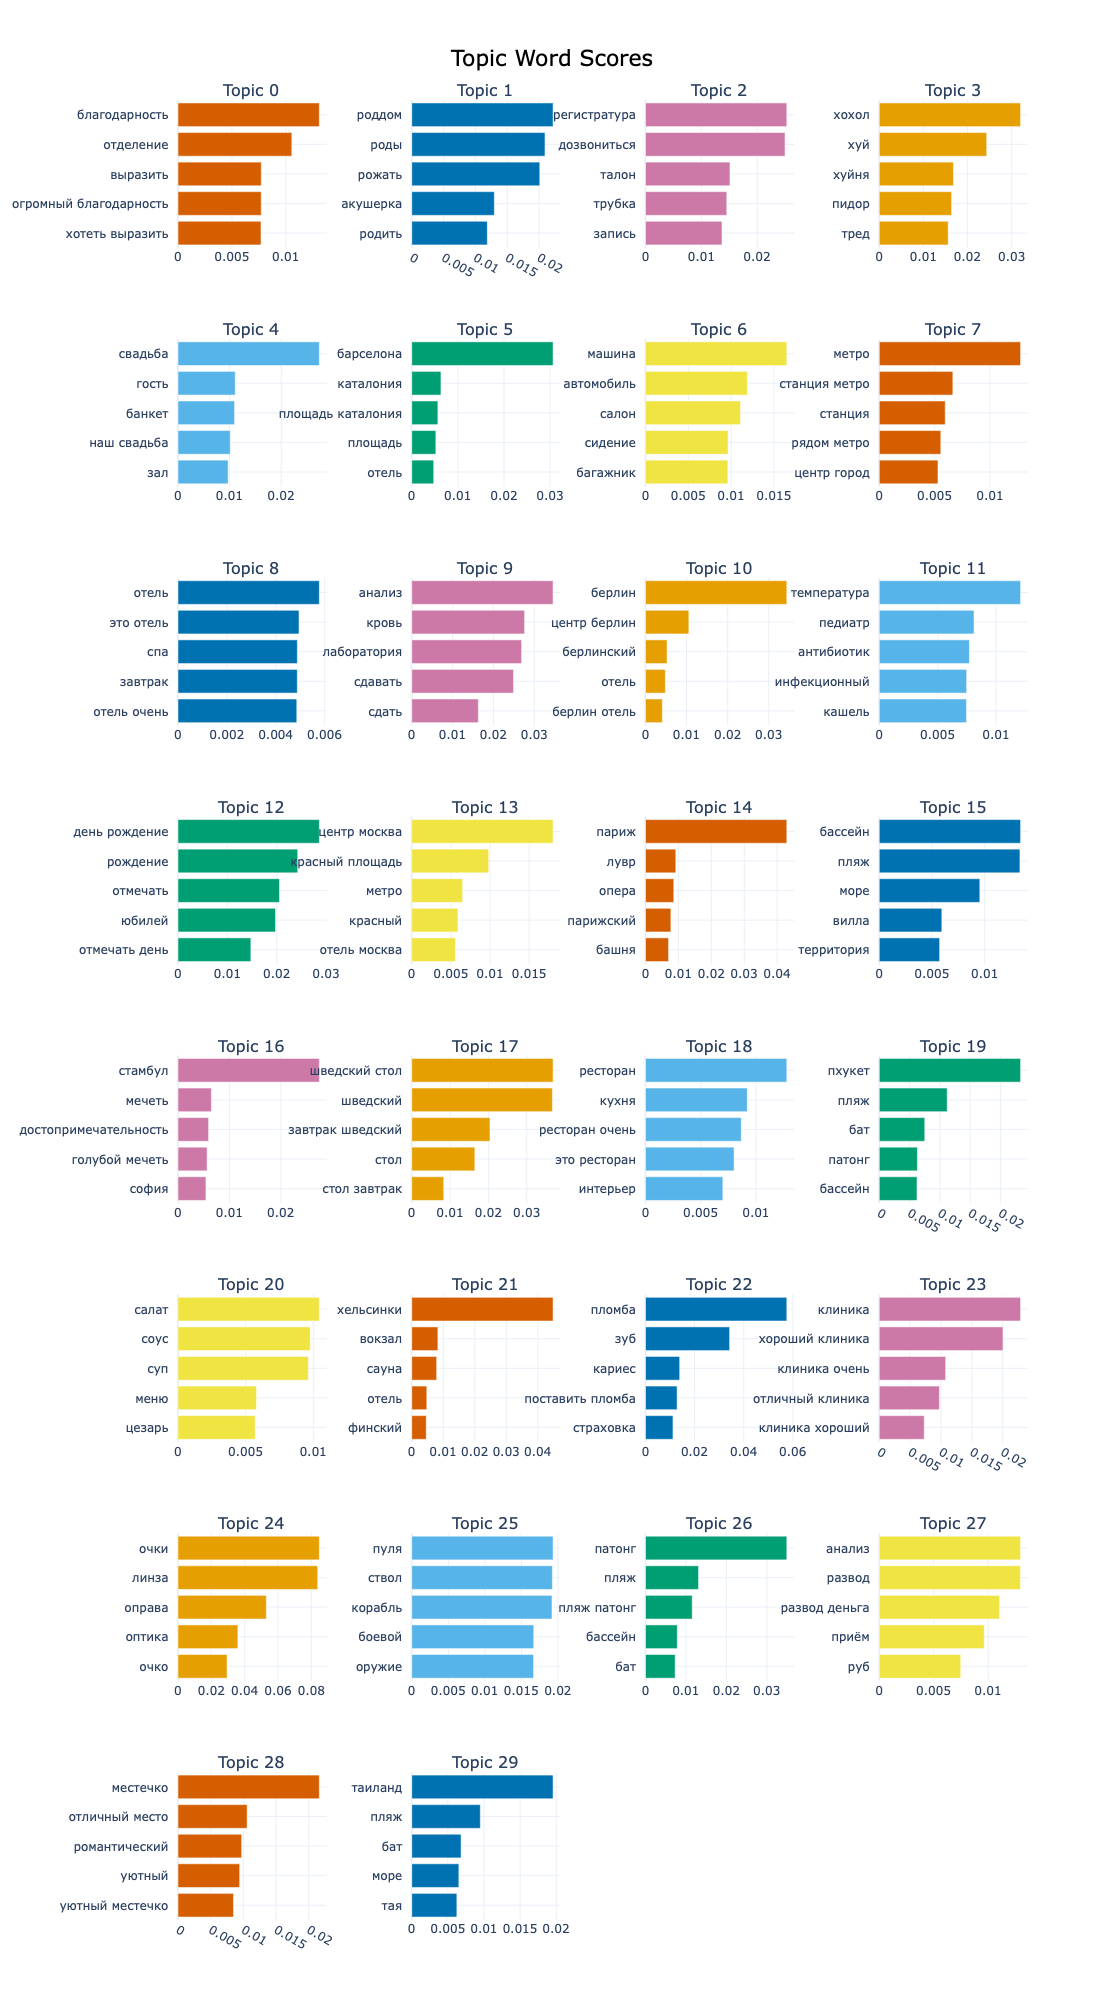

In [13]:
topic_model.visualize_barchart(top_n_topics=30)


In [15]:
bertopic_df = bertopic_df.copy()
bertopic_df["bertopic_topic"] = topics

topic_counts_default = bertopic_df["bertopic_topic"].value_counts()
outlier_share_default = (bertopic_df["bertopic_topic"] == -1).mean()

print(f"Outlier share: {outlier_share_default:.2%}")
topic_counts_default.head(20)


Outlier share: 58.06%


bertopic_topic
-1     114253
 0       6124
 1       4637
 2       2833
 3       2776
 4       2405
 5       2107
 6       1631
 7       1590
 8       1410
 9       1342
 10      1237
 11      1201
 12      1015
 13       982
 14       974
 15       918
 16       893
 17       836
 18       831
Name: count, dtype: int64

### BERTopic parameter tuning

В стандартной конфигурации `BERTopic` использует `UMAP` для снижения размерности и `HDBSCAN` для поиска плотных кластеров. На полном корпусе дефолтные параметры дали слишком большую долю outlier-документов (`Topic = -1`), поэтому параметры были настроены.

Изменения относительно базовой конфигурации:
- `n_neighbors=50` у `UMAP`: учитываем более широкую окрестность документов и делаем структуру менее локальной;
- `min_cluster_size=100` у `HDBSCAN`: не создаём слишком маленькие темы;
- `min_samples=5` у `HDBSCAN`: делаем критерий outlier менее строгим, чтобы больше документов попадало в темы.


In [17]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=50,      # default 15
    n_components=5,     
    min_dist=0.0,        
    metric="cosine",     
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,        # default  10
    min_samples=5,               # default None
    metric="euclidean",          
    cluster_selection_method="eom", 
    prediction_data=True         
)

topic_model_tuned = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

topics_tuned, _ = topic_model_tuned.fit_transform(docs, embeddings)


2026-05-07 13:41:52,730 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-07 13:46:07,114 - BERTopic - Dimensionality - Completed ✓
2026-05-07 13:46:07,117 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-07 13:46:14,401 - BERTopic - Cluster - Completed ✓
2026-05-07 13:46:14,419 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-07 13:47:02,955 - BERTopic - Representation - Completed ✓


### Tuned BERTopic results


In [18]:
topic_model_tuned.get_topic_info().head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,53231,-1_казахстан_пляж_это отель_республика,"[казахстан, пляж, это отель, республика, респу...",[В Астане состоялась презентация новой книги о...
1,0,67249,0_врач_клиника_доктор_лечение,"[врач, клиника, доктор, лечение, больница, зуб...","[Спасибо за сыночка\nМы, родители, выражаем ог..."
2,1,30861,1_салат_свадьба_официантка_суп,"[салат, свадьба, официантка, суп, соус, порция...",[Мы хотим выразить огромную признательность и ...
3,2,5933,2_двигатель_сидение_задний_багажник,"[двигатель, сидение, задний, багажник, машинка...",[ Я хотела бы оставить отзыв об авто...
4,3,3490,3_хохол_хуй_тред_блядь,"[хохол, хуй, тред, блядь, нахуй, хуйня, тупой,...","[БЕЛАРУСЬ, БЛЯТЬ, БЕЛАРУСЬ. СПИДОРСВИН, БЛЯТЬ...."
5,4,3026,4_это отель_бронь_ванная комната_забронировать,"[это отель, бронь, ванная комната, забронирова...",[Отличный отель. Останавливались в нем на 2 дн...
6,5,2184,5_берлин_берлинский_зоопарк_это отель,"[берлин, берлинский, зоопарк, это отель, отель...",[Часто бываю в Берлине и жил тут в разных гост...
7,6,2136,6_барселона_каталония_площадь каталония_испания,"[барселона, каталония, площадь каталония, испа...","[Главное, что Вас может смутить в этом отеле -..."
8,7,1643,7_лекарство_препарат_продавец_покупатель,"[лекарство, препарат, продавец, покупатель, уп...","[Неуважение, некомпетентность\nСегодня, 12 янв..."
9,8,1329,8_париж_башня_опера_парижский,"[париж, башня, опера, парижский, елисейский, е...",[Мини-отель расположен в фешенебельной части П...


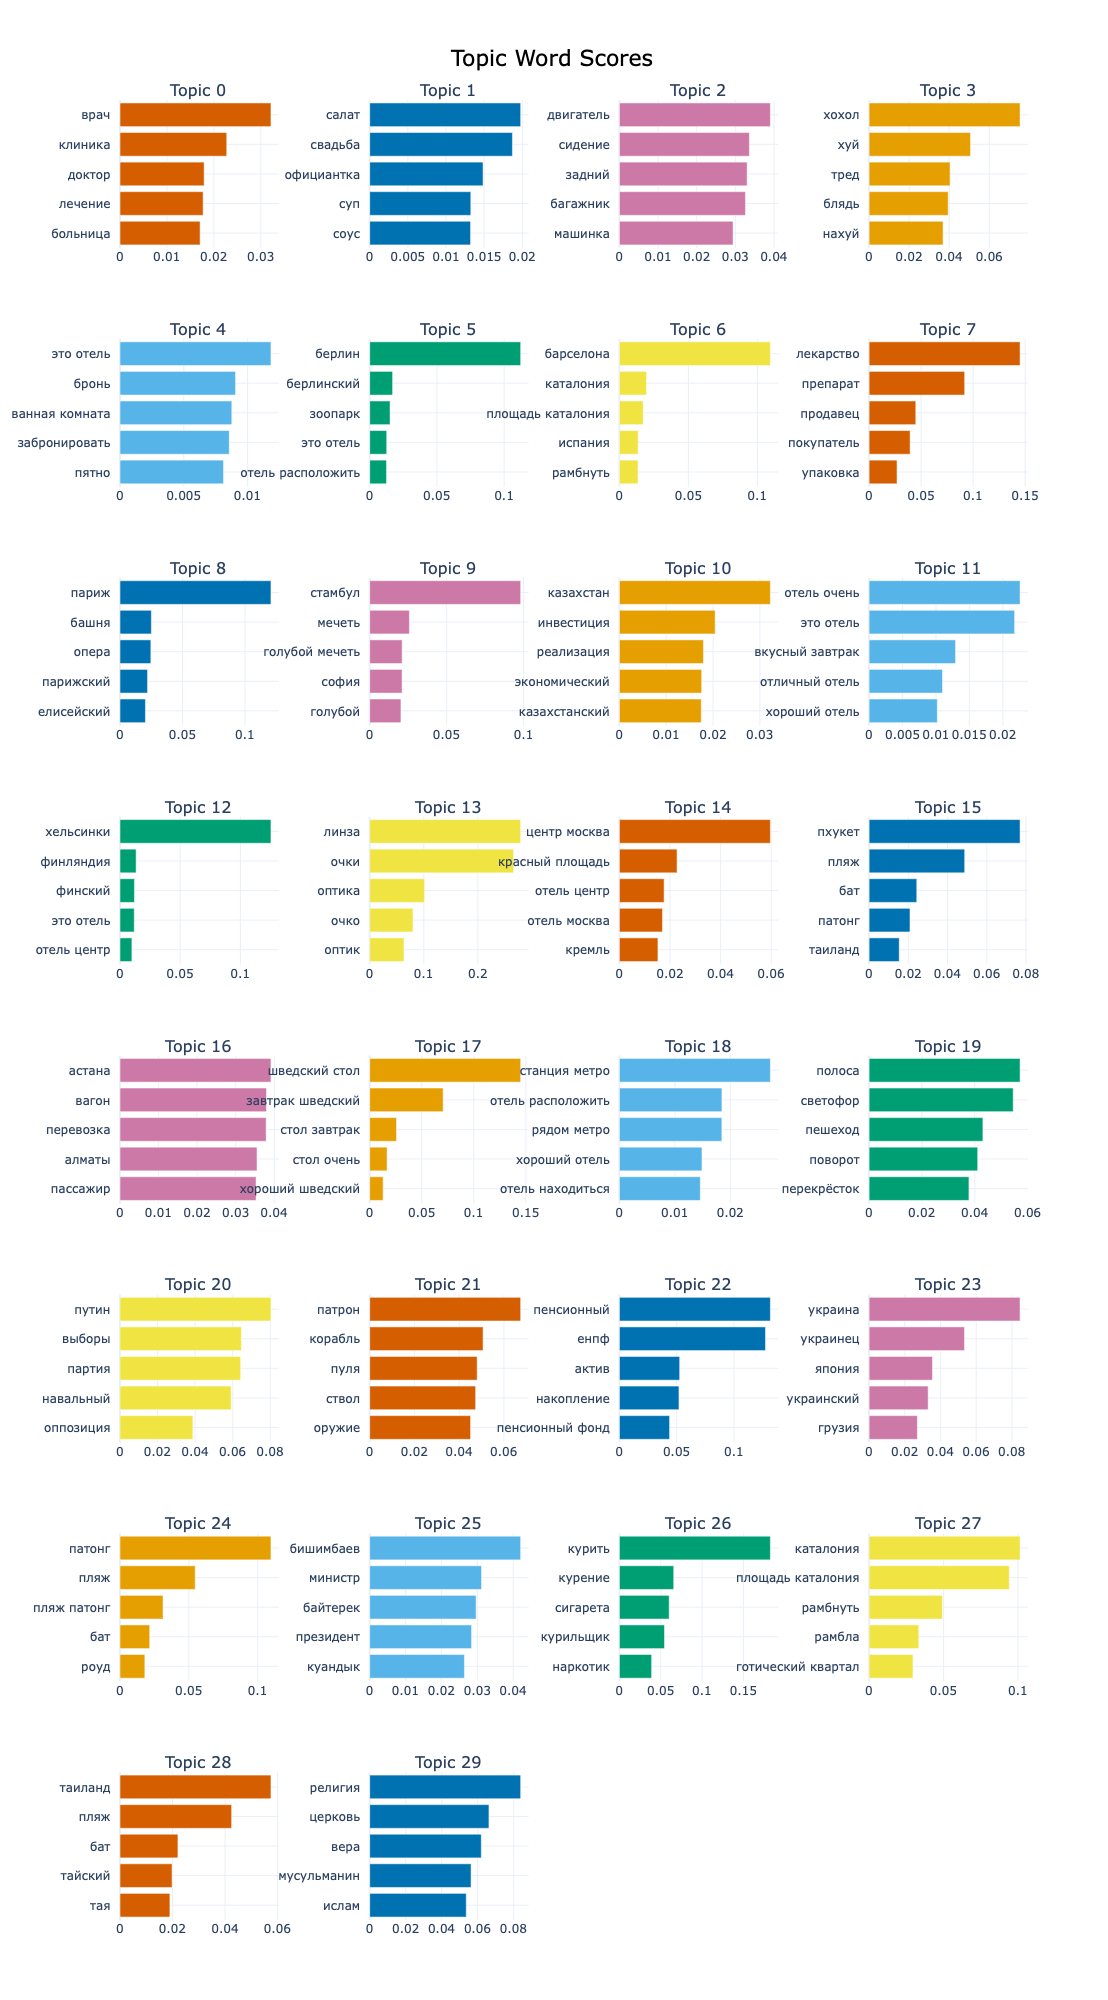

In [19]:
topic_model_tuned.visualize_barchart(top_n_topics=30)


In [20]:
bertopic_df = bertopic_df.copy()
bertopic_df["bertopic_topic"] = topics_tuned

topic_counts_tuned = bertopic_df["bertopic_topic"].value_counts()
outlier_share_tuned = (bertopic_df["bertopic_topic"] == -1).mean()

print(f"Outlier share: {outlier_share_tuned:.2%}")
topic_counts_tuned.head(20)


Outlier share: 27.05%


bertopic_topic
 0     67249
-1     53231
 1     30861
 2      5933
 3      3490
 4      3026
 5      2184
 6      2136
 7      1643
 8      1329
 9      1208
 10     1187
 11     1101
 12     1037
 13      770
 14      731
 15      720
 16      695
 17      693
 18      659
Name: count, dtype: int64

### Topic modeling summary

`NMF` + лемматизированный `TF-IDF` использовался как baseline: он выделил крупные лексические темы корпуса — отели, медицину, рестораны, автомобили, новости Казахстана, стоматологию и прочее.

`BERTopic` + `Granite embeddings` использовался как основной semantic-подход: эмбеддинги отвечают за группировку документов, а лемматизированный c-TF-IDF — за более чистое текстовое описание тем. Дефолтный `BERTopic` дал слишком большую долю outlier-документов (`Topic = -1`), поэтому были настроены параметры `UMAP`/`HDBSCAN`. После настройки доля outliers снизилась примерно с 58% до 27%, а темы остались интерпретируемыми: медицина, рестораны, автомобили, отели по городам, аптеки, финансы, транспорт, политика и другие поддомены.

Таким образом, лемматизированный `TF-IDF` + `NMF` даёт простой и понятный baseline, а `BERTopic` + embeddings лучше раскрывает семантическую структуру корпуса и узкие подтемы. Лемматизация в BERTopic не меняет эмбеддинги напрямую, но делает ключевые слова тем более аккуратными.


In [ ]:
# Освобождаем память перед классификацией
import gc

for name in [
    "embeddings", "topics", "topics_tuned", "topic_model", "topic_model_tuned",
    "topic_info", "bertopic_df", "umap_model", "hdbscan_model", "vectorizer_model"
]:
    if name in globals():
        del globals()[name]

gc.collect()

if "torch" in globals() and torch.backends.mps.is_available():
    torch.mps.empty_cache()

# 3. Sentiment classification


В качестве основной модели выбран `deepvk/RuModernBERT-small` — современный русскоязычный encoder на архитектуре `ModernBERT`.  
Модель содержит около `35M` параметров, поэтому подходит для локального fine-tuning на `Apple M1 Pro`, но при этом является более современной альтернативой классическим `RuBERT`-моделям.


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "deepvk/RuModernBERT-small"
MODEL_REVISION = "patched-tokenizer"

NUM_LABELS = 3
MAX_LENGTH = 256

id2label = {
    0: "neutral",
    1: "positive",
    2: "negative"
}

label2id = {
    "neutral": 0,
    "positive": 1,
    "negative": 2
}

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
import pandas as pd
import numpy as np
import torch
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

df_clean = pd.read_csv("df.csv")
df_clean["text"] = df_clean["text"].astype(str)
df_clean["sentiment"] = df_clean["sentiment"].astype(int)

df_clean.shape


(196786, 2)

In [44]:
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df_clean["sentiment"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=temp_df["sentiment"]
)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["sentiment"].value_counts(normalize=True).sort_index())


train: (157428, 3)
val: (19679, 3)
test: (19679, 3)

Train label distribution:
sentiment
0    0.250286
1    0.474776
2    0.274938
Name: proportion, dtype: float64


Данные разбиты в пропорции 80/10/10 со стратификацией по целевой переменной.  
Стратификация нужна из-за дисбаланса классов: распределение `neutral`, `positive` и `negative` должно быть похожим во всех частях выборки.


In [5]:
from datasets import Dataset, DatasetDict

dataset_cls = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["text", "sentiment"]],
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        val_df[["text", "sentiment"]],
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[["text", "sentiment"]],
        preserve_index=False
    ),
})

dataset_cls


DatasetDict({
    train: Dataset({
        features: ['text', 'sentiment'],
        num_rows: 157428
    })
    validation: Dataset({
        features: ['text', 'sentiment'],
        num_rows: 19679
    })
    test: Dataset({
        features: ['text', 'sentiment'],
        num_rows: 19679
    })
})

In [6]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset_cls.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset = tokenized_dataset.rename_column("sentiment", "labels")
tokenized_dataset


Map:   0%|          | 0/157428 [00:00<?, ? examples/s]

Map:   0%|          | 0/19679 [00:00<?, ? examples/s]

Map:   0%|          | 0/19679 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 157428
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 19679
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 19679
    })
})

`MAX_LENGTH=256` выбран как компромисс между качеством и скоростью.  
По `EDA` большая часть текстов существенно короче экстремальных выбросов, поэтому увеличение длины до 512 заметно замедлит обучение, но не обязательно даст сопоставимый прирост качества.


In [7]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


Основная метрика — `macro F1`, так как классы в датасете несбалансированы.  
`Accuracy` может быть завышена за счёт самого частого класса, поэтому используется только как дополнительная метрика.

Функция потерь — `CrossEntropyLoss`, стандартная функция потерь для многоклассовой классификации с взаимоисключающими классами.


In [9]:
from transformers import TrainingArguments, Trainer, set_seed

set_seed(42)

training_args = TrainingArguments(
    output_dir="rumodernbert_sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=2,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=200,
    save_total_limit=1,
    report_to="none",

    fp16=False,
    dataloader_num_workers=0,
)


In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer device:", trainer.args.device)

trainer.train()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Trainer device: mps


/Users/artemzmailov/Desktop/hackathon/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.405911,0.392390,0.822095,0.810133,0.820736
2,0.321630,0.386034,0.830174,0.818904,0.829310


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/artemzmailov/Desktop/hackathon/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9840, training_loss=0.39767340828732745, metrics={'train_runtime': 6951.5109, 'train_samples_per_second': 45.293, 'train_steps_per_second': 1.416, 'total_flos': 7350054686916480.0, 'train_loss': 0.39767340828732745, 'epoch': 2.0})

Модель обучалась 2 эпохи. После первой эпохи validation macro F1 составил около 0.810, после второй — около 0.819; validation loss также немного снизился. Поэтому явных признаков переобучения на второй эпохе не наблюдается.

Обучение заняло около 116 минут на Apple Silicon MPS. Средняя скорость обучения составила около 45 текстов в секунду.


In [11]:
test_metrics = trainer.evaluate(tokenized_dataset["test"])
test_metrics


/Users/artemzmailov/Desktop/hackathon/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.321630,0.380751,2,0.833376,0.823044,0.832760


{'eval_loss': 0.3807509243488312,
 'eval_accuracy': 0.8333756796585192,
 'eval_macro_f1': 0.8230443317470103,
 'eval_weighted_f1': 0.8327595782983405}

In [12]:
pred_output = trainer.predict(tokenized_dataset["test"])

test_logits = pred_output.predictions
test_labels = pred_output.label_ids
test_preds = test_logits.argmax(axis=1)

print(classification_report(
    test_labels,
    test_preds,
    target_names=["neutral", "positive", "negative"]
))


/Users/artemzmailov/Desktop/hackathon/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

     neutral       0.75      0.72      0.74      4926
    positive       0.85      0.87      0.86      9343
    negative       0.87      0.87      0.87      5410

    accuracy                           0.83     19679
   macro avg       0.82      0.82      0.82     19679
weighted avg       0.83      0.83      0.83     19679



На test-выборке модель показала `macro F1 = 0.823` и `accuracy = 0.833`. Значения близки к validation-метрикам, поэтому сильного расхождения между validation и test не наблюдается.

Лучше всего модель распознаёт положительные и отрицательные тексты: `F1-score` для этих классов составляет `0.86` и `0.87`. Нейтральный класс распознаётся хуже: `F1-score` равен `0.74`. Это ожидаемо для задачи тональности, так как нейтральные тексты часто находятся ближе к границе между классами и могут содержать как фактические новости, так и слабо выраженные оценки.


In [13]:
trainer.save_model("rumodernbert_sentiment_best")
tokenizer.save_pretrained("rumodernbert_sentiment_best")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('rumodernbert_sentiment_best/tokenizer_config.json',
 'rumodernbert_sentiment_best/tokenizer.json')

In [15]:
import json

with open("rumodernbert_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)


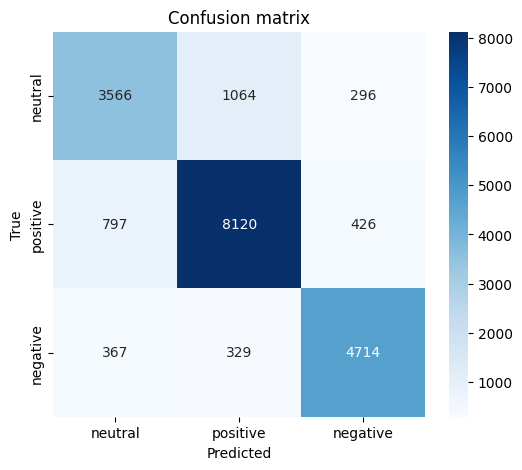

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["neutral", "positive", "negative"],
    yticklabels=["neutral", "positive", "negative"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix")
plt.show()


`Confusion matrix` показывает, что модель хорошо разделяет положительные и отрицательные тексты: ошибки между этими классами относительно редки. Основная зона ошибок связана с нейтральным классом: часть нейтральных текстов модель относит к положительным.

Это согласуется с `classification report`, где `neutral` имеет самый низкий `F1-score`. Вероятная причина — размытая граница нейтрального класса: в датасете он включает как фактические тексты, так и отзывы со слабовыраженной оценкой.


## CPU vs GPU inference speed


In [18]:
def benchmark_inference(model, tokenizer, texts, device, batch_size=64, max_length=256):
    model = model.to(device)
    model.eval()

    start = time.perf_counter()

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                max_length=max_length,
                padding=True,
                return_tensors="pt"
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            _ = model(**inputs)

    elapsed = time.perf_counter() - start

    return {
        "device": device,
        "n_texts": len(texts),
        "batch_size": batch_size,
        "time_sec": elapsed,
        "texts_per_sec": len(texts) / elapsed,
        "ms_per_text": elapsed / len(texts) * 1000,
    }


In [19]:
speed_texts = test_df["text"].astype(str).head(5000).to_list()

cpu_speed = benchmark_inference(model, tokenizer, speed_texts, "cpu", batch_size=64)

mps_speed = benchmark_inference(
    model,
    tokenizer,
    speed_texts,
    "mps",
    batch_size=64
) if torch.backends.mps.is_available() else None

pd.DataFrame([cpu_speed, mps_speed]).dropna(how="all")


,device,n_texts,batch_size,time_sec,texts_per_sec,ms_per_text
0,cpu,5000,64,46.786970,106.867362,9.357394
1,mps,5000,64,37.278616,134.125152,7.455723


Инференс на `MPS` оказался быстрее `CPU` примерно в `1.25` раза: около 134 текстов/сек против 107 текстов/сек. Разница есть, но не кратная, что ожидаемо для компактной модели и `Apple Silicon unified memory`: часть времени занимает токенизация и подготовка батчей на `CPU`.

Скорость измерялась на 5000 текстах test-выборки при одинаковом `MAX_LENGTH=256` и `batch_size=64`.


In [ ]:
# Сохранили модель и метрики; часть 3 заново загрузит модель с диска.
import gc

for name in [
    "trainer", "model", "tokenized_dataset", "dataset_cls", "pred_output",
    "test_logits", "test_preds", "test_labels", "speed_texts"
]:
    if name in globals():
        del globals()[name]

gc.collect()

if "torch" in globals() and torch.backends.mps.is_available():
    torch.mps.empty_cache()

# 4. Further improvements

## Улучшение тематического моделирования

- Сравнить несколько embedding-моделей в одном и том же `BERTopic`-пайплайне: например более крупные версии `Granite`, `Jina`, `FRIDA` или `F2LLM`. Это может улучшить семантическую группировку, особенно для смешанных новостных, форумных и отзывных текстов.
- Более системно подобрать параметры `UMAP` и `HDBSCAN`: `n_neighbors`, `min_dist`, `min_cluster_size`, `min_samples` и стратегию выбора кластеров. Эти параметры напрямую влияют на детализацию тем и долю outlier-документов.
- Разбивать очень длинные документы на фрагменты перед построением эмбеддингов. Длинные тексты могут содержать несколько тем одновременно и размывать структуру кластеров.
- Оценивать темы не только визуально, но и через topic coherence, topic diversity и ручную экспертную проверку.
- Попробовать методы с фиксированным числом кластеров, например `KMeans` или `Agglomerative Clustering`, если бизнес-задача требует, чтобы каждый документ обязательно относился к одной из заданных тем без класса `-1`.

## Улучшение качества и скорости классификатора

- Подобрать гиперпараметры обучения: `learning_rate`, число эпох, `scheduler`, `warmup ratio`, `batch size` и `MAX_LENGTH`. Это позволит явно управлять компромиссом между качеством и скоростью.
- Попробовать `RuModernBERT-base` вместо `RuModernBERT-small`, если доступно больше вычислительных ресурсов. Более крупный `encoder` может улучшить качество, особенно для нейтрального класса.
- Использовать `class weights` или `focal loss`, если нейтральный класс остаётся основным источником ошибок.
- Вручную проанализировать и при необходимости переоценить спорные neutral-примеры. `Confusion matrix` показывает, что граница между `neutral` и `positive` — самая слабая часть разметки.
- Выполнить `distillation` обученной модели в меньшую student-модель, чтобы ускорить инференс с ограниченной потерей качества.
- Оптимизировать `CPU`-инференс через `ONNX Runtime` или `dynamic quantization`. Это естественное направление для факультативной части 3.
- Кэшировать токенизацию и подобрать `batch size` для production-like инференса.
- На `CUDA GPU` можно использовать `mixed precision`, `FlashAttention`, `fused optimizers` или `torch.compile`. В текущем эксперименте эти оптимизации не применялись, так как обучение выполнялось на `Apple Silicon/MPS`.


# 5. Optional: CPU inference optimization

В факультативной части проверяется CPU-ориентированная оптимизация инференса обученного классификатора. В качестве основного воспроизводимого способа выбран `torch.compile`.

`torch.compile` не меняет веса модели и не требует переобучения: PyTorch пытается скомпилировать вычислительный граф и применить низкоуровневые оптимизации выполнения. Это простой способ проверить, даст ли оптимизация графа ускорение относительно обычного `PyTorch eager CPU`.

Дополнительно были проверены ещё два CPU-направления: `dynamic quantization` через `qnnpack` и экспорт в `ONNX Runtime CPU`. В текущем окружении `Apple Silicon` эти методы не дали ускорения относительно `PyTorch eager CPU`. Вероятная причина в том, что многие CPU-оптимизации для BERT/ONNX лучше раскрываются на `x86` CPU с `oneDNN`, `VNNI` и `AVX512`, а не на `ARM macOS`. Для `Apple Silicon` более перспективным deployment-направлением является `Core ML / Neural Engine`, но это уже не CPU-only оптимизация и выходит за рамки формулировки задания.

In [95]:
import copy
import time

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [96]:
MODEL_DIR = "rumodernbert_sentiment_best"
MAX_LENGTH = 256
OPT_TEST_SIZE = 5_000
BATCH_SIZE = 64

try:
    test_df
except NameError:
    df_clean = pd.read_csv("df.csv")
    _, temp_df = train_test_split(
        df_clean,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=df_clean["sentiment"]
    )
    _, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=42,
        shuffle=True,
        stratify=temp_df["sentiment"]
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
base_cpu_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to("cpu")
base_cpu_model.eval()

opt_eval_df = test_df.head(OPT_TEST_SIZE).copy()
opt_texts = opt_eval_df["text"].astype(str).to_list()
opt_labels = opt_eval_df["sentiment"].to_numpy()

print("Model loaded from:", MODEL_DIR)
print("Optimization benchmark size:", len(opt_eval_df))

Loading weights:   0%|          | 0/78 [00:00<?, ?it/s]

Model loaded from: rumodernbert_sentiment_best
Optimization benchmark size: 5000


In [97]:
def predict_with_model(model, tokenizer, texts, batch_size=64, max_length=256, desc="CPU inference"):
    model.eval()
    all_preds = []
    start = time.perf_counter()

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=desc):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts,
                truncation=True,
                max_length=max_length,
                padding=True,
                return_tensors="pt"
            )
            logits = model(**inputs).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)

    elapsed = time.perf_counter() - start
    return np.concatenate(all_preds), elapsed

In [98]:
compiled_cpu_model = torch.compile(
    copy.deepcopy(base_cpu_model),
    mode="reduce-overhead"
)
compiled_cpu_model.eval()

# Первый короткий прогон нужен, чтобы torch.compile подготовил граф
_ = predict_with_model(
    compiled_cpu_model,
    tokenizer,
    opt_texts[:128],
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    desc="torch.compile warm-up"
)

torch.compile warm-up:   0%|          | 0/2 [00:00<?, ?it/s]

In [99]:
eager_preds, eager_time = predict_with_model(
    base_cpu_model,
    tokenizer,
    opt_texts,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    desc="PyTorch eager CPU"
)

compiled_preds, compiled_time = predict_with_model(
    compiled_cpu_model,
    tokenizer,
    opt_texts,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    desc="torch.compile CPU"
)

PyTorch eager CPU:   0%|          | 0/79 [00:00<?, ?it/s]

torch.compile CPU:   0%|          | 0/79 [00:00<?, ?it/s]

In [100]:
compile_results = pd.DataFrame([
    {
        "model": "PyTorch eager CPU",
        "accuracy": accuracy_score(opt_labels, eager_preds),
        "macro_f1": f1_score(opt_labels, eager_preds, average="macro"),
        "weighted_f1": f1_score(opt_labels, eager_preds, average="weighted"),
        "time_sec": eager_time,
        "texts_per_sec": len(opt_texts) / eager_time,
        "ms_per_text": eager_time / len(opt_texts) * 1000,
    },
    {
        "model": "torch.compile CPU",
        "accuracy": accuracy_score(opt_labels, compiled_preds),
        "macro_f1": f1_score(opt_labels, compiled_preds, average="macro"),
        "weighted_f1": f1_score(opt_labels, compiled_preds, average="weighted"),
        "time_sec": compiled_time,
        "texts_per_sec": len(opt_texts) / compiled_time,
        "ms_per_text": compiled_time / len(opt_texts) * 1000,
    },
])

compile_results["speedup_vs_eager"] = (
    compile_results["texts_per_sec"] / compile_results.loc[0, "texts_per_sec"]
)
compile_results["macro_f1_delta"] = (
    compile_results["macro_f1"] - compile_results.loc[0, "macro_f1"]
)

compile_results

,model,accuracy,macro_f1,weighted_f1,time_sec,texts_per_sec,ms_per_text,speedup_vs_eager,macro_f1_delta
0,PyTorch eager CPU,0.8348,0.824026,0.833712,46.661827,107.153969,9.332365,1.000000,0.0
1,torch.compile CPU,0.8348,0.824026,0.833712,48.758666,102.545873,9.751733,0.956996,0.0


### Итог проверки в текущем окружении  
`torch.compile` сохранил качество модели, но не дал устойчивого ускорения CPU-инференса на `Apple Silicon`: скорость находится примерно на уровне `PyTorch eager CPU` (`~1.0x`), а небольшие отличия между запусками укладываются в шум измерения.

Практический вывод: в текущем окружении `torch.compile` нельзя считать значимой CPU-оптимизацией по скорости, но сама процедура корректно показывает проверку оптимизации и отсутствие деградации качества. Для production CPU-инференса на `x86` стоит отдельно проверить `ONNX Runtime` / `OpenVINO` / `oneDNN` и динамическую квантизацию на целевом сервере. Для `Apple Silicon` более перспективны `MPS` или `Core ML / Neural Engine`, но это уже не CPU-only сценарий.